#Πυραμίδες Εικόνων

Σε αρκετά προβλήματα ανάλυσης εικόνας, δεν γνωρίζουμε ποια είναι η κατάλληλη ανάλυση για την εικόνα που θα πρέπει να χρησιμοποιήσουμε. Από μελέτες πάνω στα βιολογικά οπτικά συστήματα, έχει παρατηρηθεί ότι αυτά λειτουργούν βασιζόμενα σε ιεραρχία κλιμάκων. Λαμβάνοντας αυτό υπόψην, δημιουργήθηκαν αλγόριθμοι για τη ψηφιακή επεξεργασία εικόνων βασισμένοι σε πυραμίδες με διαφορετικές κλίμακες της εικόνας.

Μια τέτοια πυραμίδα μπορεί, για παράδειγμα, να είναι πολύ χρήσιμη στην επιτάχυνση της αναζήτησης ενός αντικειμένου σε μία εικόνα βρίσκοντας πρώτα μια μικρότερη παρουσία αυτού του αντικειμένου σε πιο χονδροειδές επίπεδο της πυραμίδας και στη συνέχεια αναζητώντας το αντικείμενο πλήρους ανάλυσης μόνο κοντά στην περιοχή, όπου έγινε η ανιχνεύση στο χονδροειδές επιπέδο, στο λεπτομερέστερο επίπεδο. (π.χ. εντοπισμός προσώπων που περιέχονται σε μια εικόνα).

Τέλος, οι πυραμίδες εικόνας είναι εξαιρετικά χρήσιμες για την εκτέλεση λειτουργιών επεξεργασίας πολλαπλών κλιμάκων όπως η ανάμειξη εικόνων διατηρώντας παράλληλα τις λεπτομέρειες.



**Παραδοσιακή πυραμίδα εικόνας**

![](https://drive.google.com/uc?id=14dJoebazISQ7zrvRro2ImGg_5mhGaGTH)

Κάθε επίπεδο έχει τη μισή ανάλυση (πλάτος και ύψος), και ως εκ τούτου το ένα τέταρτο των pixel, του γονικού επιπέδου.

*Λόγω του προβλήματος της αναδίπλωσης που προκύπτει δεν χρησιμοποιείται στην πράξη.*

**Laplacian πυραμίδα των Burt και Adelson.**

Η πιο γνωστή και ευρέως χρησιμοποιούμενη πυραμίδα είναι η Laplacian πυραμίδα των Burt και Adelson.

([Burt, P. J. and Adelson, E. H. (1983a). The Laplacian pyramid as a compact image code. IEEE Transactions on Communications, COM-31(4):532–540. ](http://persci.mit.edu/pub_pdfs/pyramid83.pdf)).

Για να κατασκευάσουμε την πυραμίδα, θα περάσουμε την αρχική εικόνα από ένα βαθυπερατό φίλτρο (Gaussian blur), το οποίο θα μειώνει τις υψηλές συχνότητες, διατηρώντας τις κύριες δομές της εικόνας και αφαιρώντας λεπτομέρειες.

Έπειτα θα την υποδειγματοληπτήσουμε με ρυθμό r = 2, δηλαδή διατηρείται μόνο το ένα ανά δύο εικονοστοιχεία (pixels) σε κάθε διάσταση (πλάτος και ύψος). Έτσι, η νέα εικόνα έχει το 1/4 των pixels της αρχικής.

> Αν η αρχική εικόνα έχει διαστάσεις 𝑊×𝐻 (πλάτος × ύψος), τότε περιέχει συνολικά: 𝑁=𝑊×𝐻

Όταν υποδειγματοληπτούμε με r = 2, διατηρούμε κάθε δεύτερο pixel τόσο οριζόντια όσο και κάθετα. Αυτό σημαίνει:

Νέο πλάτος:  𝑊′=𝑊/2
Νέο ύψος:    𝐻′=𝐻/2
Άρα, η νέα εικόνα έχει συνολικά: 𝑁′=𝑊′×𝐻′=𝑊/2×𝐻/2=𝑊×𝐻/4
Δηλαδή, ο συνολικός αριθμός των pixels μειώνεται στο 1/4 της αρχικής εικόνας.


Η διαδικασία συνεχίζεται επαναληπτικά για κάθε νέο επίπεδο, δημιουργώντας μια σειρά από εικόνες G₀, G₁, G₂, ..., Gₙ.

Μία ακολουθία χαμηλοδιαβατών φιλτραρισμένων εικόνων G0, G1, …, GN μπορεί να
αποκτηθεί συνελίσσοντας επαναληπτικά μία μικρή συνάρτηση βάρους με μία
εικόνα. Με αυτή την τεχνική, η συχνότητα δειγματοληψίας της εικόνας
μειώνεται με κάθε επανάληψη έτσι ώστε το εύρος ζώνης να μειώνεται σε
ομοιόμορφα βήματα μιας οκτάβας. Μείωση δείγματος επίσης σημαίνει ότι το
κόστος του υπολογισμού κρατιέται στο ελάχιστο.

Επειδή όλα τα επίπεδα στην πυραμίδα σχετίζονται με
 ρυθμό δειγματοληψίας r = 2, αυτό το είδος πυραμίδας είναι γνωστό ως *πυραμίδα οκτάβας*.

Ο Burt και ο Adelson πρότειναν αρχικά έναν πυρήνα της μορφής:

$$\left[ \begin{array}{ccc}c& b& a& b& c\end{array}\right]$$

με $b=\frac{1}{4}$ και $c=\frac{1}{4}- \frac{a} {2}$.

![reduce.JPG](https://drive.google.com/uc?id=1-k3_NsuGI4Z_qxgpXg6pktcBXr4ndki5)


Στην πράξη, χρησιμοποιείται ένα $a=\frac{3}{8}$, το οποίο οδηγεί στο διωνυμικό πυρήνα, που προσεγγίζει την Gaussian κατανομή:

$$\frac{1}{16}\left[\begin{array}{ccccc}1& 4& 6& 4& 1\end{array}\right]$$

το οποίο είναι ιδιαίτερα εύκολο υπολογιστικά να εφαρμοστεί, χρησιμοποιώντας μετατοπίσεις και προσθέσεις (αυτό ήταν σημαντικό στις μέρες που οι πολλαπλασιαστές ήταν ακριβοί).

Ο λόγος που ονομάζουν την πυραμίδα που προέκυψε, ως *πυραμίδα Gaussian* είναι ότι οι επαναλαμβανόμενες συνελίξεις με το διωνυμικό πυρήνα συγκλίνουν με Gaussian κατανομή.



**Διαδικασία Δημιουργίας της Πυραμίδας Laplacian**

Δημιουργία της Πυραμίδας Gaussian 𝐺𝑛

- Ξεκινάμε από την εικόνα υψηλής ανάλυσης και δημιουργούμε τα επίπεδα Gaussian.

Παρεμβολή (Upsampling) της Gaussian εικόνας χαμηλότερης ανάλυσης
- Μεγεθύνουμε την εικόνα με interpolation (αύξηση δείγματος ↑2) για να επιστρέψει στην αρχική της ανάλυση.


![](https://drive.google.com/uc?id=1mIfKLbo1viTS7J6dKOhM2NiEaOS3QEcu)

Υπολογισμός της Laplacian εικόνας 𝐿𝑛
- Αφαιρούμε την παρεμβολή της Gaussian εικόνας από την αρχική:𝐿𝑛=𝐺𝑛−Upsampled(𝐺𝑛+1)

    Η διαφορά αυτή κρατά μόνο τις λεπτομέρειες και τις υψηλές συχνότητες που χάθηκαν κατά τη μετάβαση στην επόμενη Gaussian εικόνα.

Επανάληψη για όλα τα επίπεδα

Δημιουργούμε τη σειρά εικόνων:𝐿0,𝐿1,𝐿2,...,𝐿𝑁

Γιατί λέγεται Laplacian Pyramid;
Η διαδικασία της αφαίρεσης χαμηλών συχνοτήτων από την αρχική εικόνα μοιάζει με την Laplacian απόκριση ενός φίλτρου που ανιχνεύει τις λεπτομέρειες της εικόνας.



Στην ακόλουθη εικόνα, τα έντονα κίτρινα πλαίσια ($L_1,L_2$) σχηματίζουν την πυραμίδα Gauss, η οποία λαμβάνεται με διαδοχικά φιλτράρισμα χαμηλής διέλευσης και υποδειγματοληψίας ($\downarrow 2$) της εικόνας εισόδου.

Τα μπλε πλαίσια αποτελούν την ζωνοπερατή εικόνα (την "Laplacian" εικόνα του band-pass) και υπολογίζονται με την αφαίρεση της παρεμβολής ($\uparrow2$) της εικόνας της πυραμίδας Gaussian χαμηλότερης ανάλυσης από την αρχική εικόνα.


![](https://drive.google.com/uc?id=1L_2Y9rYKfSbN8F-jYq-kidpO_DpzEgcw)

Το πλαίσιο $Q$ υποδεικνύει ποσοτικοποίηση ή κάποια άλλη επεξεργασία πυραμίδας, π.χ. αφαίρεση θορύβου μέσω πυρήνα.

Όπως και με την πυραμίδα Gauss, ο όρος Laplacian είναι λίγο παραπλανητικός, καθώς οι εικόνες του band-pass είναι πραγματικά διαφορές των (κατά προσέγγιση) Gauss:
$$DoG(I;σ_1,σ_2)=G_{σ_1}*Ι -G_{σ_2}*Ι= (G_{σ_1}-G_{σ_2})*Ι$$

Ένας Laplacian του Gaussian είναι στην πραγματικότητα η δεύτερη παράγωγό:

$$LoG(Ι;σ)= \nabla^2(G_σ*Ι)=\nabla^2(G_σ)*Ι$$

όπου το $\nabla$ είναι o Laplacian (τελεστής) μιας συνάρτησης.

Οι Laplacian of Gaussian έχουν "κομψές" μαθηματικές ιδιότητες οι οποίες έχουν μελετηθεί ευρέως και μπορούν να χρησιμοποιηθούν για μια ποικιλία εφαρμογών, συμπεριλαμβανομένης της ανίχνευσης ακμών.




## Gaussian Scale Space (Gaussian pyramid)

Μία ακολουθία χαμηλοδιαβατών φιλτραρισμένων εικόνων G0, G1, …, GN μπορεί να
αποκτηθεί συνελίσσοντας επαναληπτικά μία μικρή συνάρτηση βάρους με μία
εικόνα. Με αυτή την τεχνική, η συχνότητα δειγματοληψίας της εικόνας
μειώνεται με κάθε επανάληψη έτσι ώστε το εύρος ζώνης να μειώνεται σε
ομοιόμορφα βήματα μιας οκτάβας και συνεπώς να ελαχιστοποιείται το
κόστος του υπολογισμού.

H $N$-επιπέδων Gaussian πυραμίδα μιας εικόνας $I$ ορίζεται ως:

\begin{equation}
  \left\{\begin{array}{rcl}
    L^0 & = & I \\
    L^{n+1} & = & \text{REDUCE}(L^n);~n\in\{0,1,\cdots,N-1\}
  \end{array}\right.
\end{equation}


όπου ο τελεστής $\text{REDUCE}(s)$ είναι η συνέλιξη της εικόνας $I$ με τον συμμετρικό πυρήνα $w=\{\frac{1}{16}, \frac{4}{16}, \frac{6}{16}, \frac{4}{16}, \frac{1}{16}\}$ (1D kernel). Η 2D έκδοσή του μπορεί να επεκταθεί ή η 1D μπορεί να εφαρμοστεί στις σειρές και στη συνέχεια στις στήλες ή αντίστροφα.

Ο χώρος κλίμακας Gauss (Gauss scale space) παρουσιάζει πολλές ενδιαφέρουσες ιδιότητες:

1. *Χωρική ομοιογένεια (Spatial homogeneity)*: όλες οι τοποθεσίες στην εικόνα φιλτράρονται με το ίδιο κέρδος.
2. *Χωρική ισοτροπία (Spatial isotropy)*: όλες οι δομές αντιμετωπίζονται με ομοιογένεια ανεξάρτητα από τον προσανατολισμό τους.
3. *Χωρική αναδρομή κλίμακας (Spatial scale invariace)*: το κέρδος του φιλτραρίσματος είναι ανεξάρτητο από το μέγεθος των αντικειμένων της εικόνας.
4. *Γραμμικότητα (Linearity*)*: το φιλτράρισμα πραγματοποιείται με μια συνέλιξη, η οποία είναι μία γραμμική πράξη.

Το τελευταίο στάδιο του $\text {REDUCE}(\cdot) $ είναι η υποδειγματοληψία της φιλτραρισμένης εικόνας.

Αυτό είναι ένα στάδιο χωρίς απώλειες (lossless - χωρίς aliasing) μόνο στην περίπτωση που τα μισά στοιχεία υψηλής συχνότητας των $L^n$ δεν είναι διαθέσιμα σε $ L^{n + 1}$.

Παρατηρήστε ότι, ως συνέπεια του αποδεκατισμού, η συνολική ενέργεια των $ L ^ {n + 1} $ θα είναι, κατά μέσο όρο, το 1/4 της ενέργειας των $ L ^ n $.


### Gaussian pyramid

\# Εισαγωγή του [urllib.request — extensible library for opening URLs](https://docs.python.org/3.0/library/urllib.request.html) module, το [urllib](https://docs.python.org/3/library/urllib.html) package περιλαμβάνεται στο standard library.

In [ ]:
import urllib.request

Εισαγωγή του [Python bindings](http://docs.opencv.org/3.0-beta/doc/py_tutorials/py_setup/py_intro/py_intro.html) από το [OpenCV](http://docs.opencv.org/3.0-beta/index.html). Εγκατάσταση με "`sudo pip3 install opencv-python`"([OpenCV-Python Tutorials](http://docs.opencv.org/trunk/d6/d00/tutorial_py_root.html)).

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Ζητά την [lena image](https://en.wikipedia.org/wiki/Lenna). Αυτό το function επιστρέφει ένα file-like object.

In [ ]:
HTTP_response = urllib.request.urlopen('http://www.image.ntua.gr/~tpar/LABimage/lena.png')

[Διάβαζει](https://docs.python.org/3/tutorial/inputoutput.html) το πλήρες "file" `HTTP_response` ως <a href="https://docs.python.org/3/library/functions.html#bytes">bytes object</a>. Αυτό το (<a href="https://en.wikibooks.org/wiki/Python_Programming/Data_Types#Mutable_vs_Immutable_Objects">immutable</a>) αντικείμενο μετασχηματίζεται σε(<a href="https://en.wikibooks.org/wiki/Python_Programming/Data_Types#Mutable_vs_Immutable_Objects">mutable</a>) <a href="https://docs.python.org/3/library/functions.html#bytearray">bytearray object</a>, όπως απαιτεί το NumPy's [asarray](https://docs.scipy.org/doc/numpy/reference/generated/numpy.asarray.html) (function) converter. Το τελικό αποτέλεσμα είναι ένα [array](https://docs.scipy.org/doc/numpy/reference/generated/numpy.array.html) object που περιέχει unsigned integers των 8 bits.

In [ ]:
arr = np.asarray(bytearray(HTTP_response.read()), dtype=np.uint8)

In [ ]:
BGR = cv2.imdecode(arr,-1)

Μετατροπή της εικόνας σε YCrCb [color space](http://docs.opencv.org/2.4/modules/imgproc/doc/miscellaneous_transformations.html#cvtcolor).

In [ ]:
Y = cv2.cvtColor(BGR, cv2.COLOR_BGR2YCrCb)[:,:,0]
#tmp = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
#Y = tmp

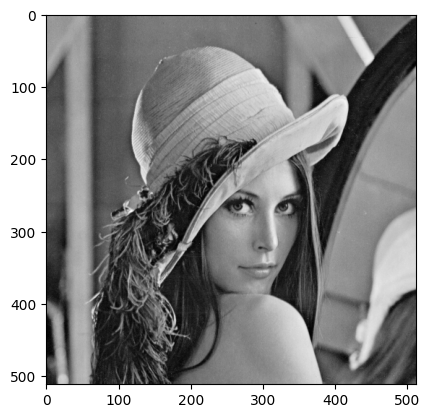

In [ ]:
plt.imshow(Y, cmap="gray")

Υπολογίζουμε την πυραμίδα και χρησιμοποιούμε μία  <a href="https://docs.python.org/3/library/stdtypes.html#sequence-types-list-tuple-range">λίστα</a> για να αποθηκεύσουμε τα επίπεδα της πυραμίδας

In [ ]:
N = 5 # Number of levels of the pyramid
L = [Y] # L^0 (the base of the pyramid)

Εφαρμόζουμε το OpenCV's <a href="http://docs.opencv.org/3.1.0/d4/d86/group__imgproc__filter.html#gaf9bba239dfca11654cb7f50f889fc2ff">pyrDown</a> low-pass filter και υποδειγματοληπτούμε την εικόνα. Αναλυτικότερα [εδώ](http://docs.opencv.org/master/dc/dff/tutorial_py_pyramids.html).

In [ ]:
for n in range(N-1):
    print(n, len(L), len(L[n]))
    L.append(cv2.pyrDown(L[n]))

0 1 512
1 2 256
2 3 128
3 4 64


Text(0.5, 1.0, 'L[4]')

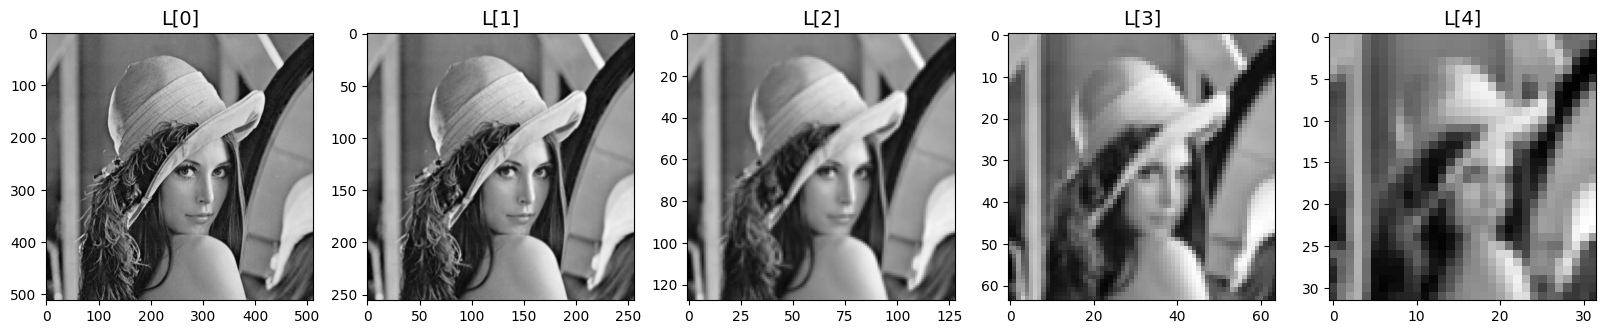

In [ ]:
f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))

ax0.imshow(L[0], cmap="gray")
ax0.set_title('L[0]', fontsize=14)
ax1.imshow(L[1], cmap="gray")
ax1.set_title('L[1]', fontsize=14)
ax2.imshow(L[2], cmap="gray")
ax2.set_title('L[2]', fontsize=14)
ax3.imshow(L[3], cmap="gray")
ax3.set_title('L[3]', fontsize=14)
ax4.imshow(L[4], cmap="gray")
ax4.set_title('L[4]', fontsize=14)


## Laplacian pyramid (Laplacian Pyramid Transform) (LPT)

### Forward transform

Σε μια Gaussian πυραμίδα, η εικόνα $L^{N-1}$ (top level) μπορεί να χρησιμεύσει ως πρόβλεψη για την εικόνα $ L ^ {N − 2} $ (επόμενο παρακάτω επίπεδο) και εάν αυτή η πρόβλεψη (η παρεμβολή $ L ^ {N-1} $) αφαιρεθεί σε $ L ^ {N- 2} $, το προκύπτον σήμα σφάλματος $ H ^ {N-2} $ μπορεί να έχει χαμηλότερη εντροπία από το αρχικό $ L ^ {N-2} $.

Αυτή η διαδικασία μπορεί να εφαρμοστεί στην πλήρη πυραμίδα Gauss, επίπεδο προς επίπεδο, λαμβάνοντας μια πυραμίδα Laplacian μέσω:

\begin{equation}
  \left\{\begin{array}{rcl}
    H^{N-1} & = & L^{N-1} \text{ /* the top level of the Gaussian pyramid */}\\
    H^n     & = & L^n - \text{EXPAND}(L^{n+1});~n\in\{N-2,N-3,\cdots,0\}
\end{array}\right.
\end{equation}


Ο EXPAND operator εκτελεί 1/2-subpixel διδιάστατη παρεμβολή

### LPT of Lena

In [ ]:
H = [L[N-1]]
for n in range(N-1):
    interpolation = cv2.pyrUp(L[N-n-1])
    difference = L[N-n-2] - interpolation + 128  #Προσθέτουμε 128 για να διατηρήσουμε την τιμή των pixel σε έγκυρο εύρος (0-255) δεδομένου ότι η διαφορά μπορεί να έχει αρνητικές τιμές
    H.append(difference)
H.reverse()

Στις εικόνες διαφορών ή σφάλματος της λαπλασιανής πυραμίδας, η πλειονότητα των τιμών συγκεντρώνονται γύρω από το 0 (παραπάνω παρουσιάζονται γύρω από το 128 λόγω ενός αντίστοιχου offset που έχει προστεθεί).

Text(0.5, 1.0, 'H[4]')

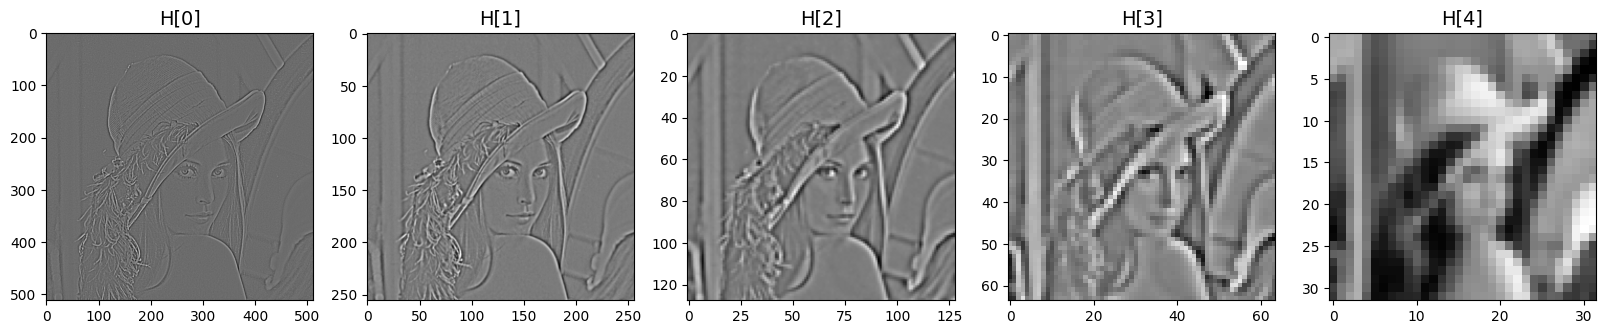

In [ ]:
f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))

ax0.imshow(H[0], cmap="gray") # Base of the pyramid
ax0.set_title('H[0]', fontsize=14)
ax1.imshow(H[1], cmap="gray")
ax1.set_title('H[1]', fontsize=14)
ax2.imshow(H[2], cmap="gray")
ax2.set_title('H[2]', fontsize=14)
ax3.imshow(H[3], cmap="gray")
ax3.set_title('H[3]', fontsize=14)
ax4.imshow(H[4], cmap="gray")
ax4.set_title('H[4]', fontsize=14)

Υπολογισμός και σχεδίαση των ιστογραμμάτων της πυραμίδας ([`cv2.calcHist()`](http://docs.opencv.org/3.1.0/d1/db7/tutorial_py_histogram_begins.html))

0
1
2
3


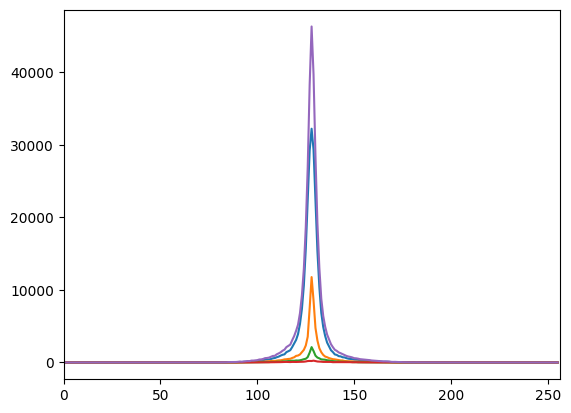

In [ ]:
sum_hist = np.zeros([256,1], np.float64)
for n in range(N-1):
    print(n)
    hist = cv2.calcHist([H[n]], [0], None, [256], [0, 256])
    plt.plot (hist)
    sum_hist += hist
plt.plot(sum_hist)
plt.xlim([0,256])
plt.show()

Για κάθε επίπεδο 𝑛 της πυραμίδας (από 0 έως 𝑁−1), υπολογίζεται ο αριθμός των pixel στο επίπεδο 𝑛. Οι διαστάσεις κάθε επιπέδου της πυραμίδας δίνονται από:
$𝑊𝑛=\frac{𝑊+1}{2^n}, 𝐻𝑛=\frac{𝐻+1}{2^𝑛}$
όπου 𝑊,𝐻 είναι οι διαστάσεις της αρχικής εικόνας 𝑌.
Ο τελεστής >> n αντιστοιχεί σε δυαδική ολίσθηση προς τα δεξιά, δηλαδή διαίρεση με $2^𝑛$
Αυτό προσεγγίζει το πλήθος των στοιχείων κάθε επιπέδου της πυραμίδας και το προσθέτει στη μεταβλητή n_pels. Το πλήθος των στοιχείων της πυραμίδας είναι:

In [ ]:
n_pels = 0
for n in range(N):
    n_pels += ((Y.shape[0]+1) >> n) * ((Y.shape[1]+1) >> n)

In [ ]:
print("Number of elements in the original image =", Y.shape[0]*Y.shape[1])

Number of elements in the original image = 262144


In [ ]:
print("Number or elements in (a component of) the pyramid =", n_pels, "(",100.*(n_pels/(1.*Y.shape[0]*Y.shape[1])-1),"% of increment)")

Number or elements in (a component of) the pyramid = 350209 ( 33.59413146972656 % of increment)


### Εντροπία Εικόνας
#####  *Τι είναι εντροπία (entropy) εικόνας;*
Ο (θεωρητικά) ελάχιστος αριθµός από bits ανά pixel (τιµή φωτεινότητας) που χρειάζεται για την κωδικοποίηση µιας εικόνας.


##### *Πως υπολογίζεται η εντροπία µιας εικόνας;*
Με βάση την εξίσωση Shannon:
$$Ε=-\sum_{k=1}^{K}P_Klog_2P_k$$
όπου $K$ o αριθµός των διαφορετικών τιµών φωτεινότητας που υπάρχουν στη εικόνα και $P_k$ η πιθανότητα εµφάνισης της τιµής φωτεινότητας k.


##### *Πως υπολογίζονται οι πιθανότητες $P_k$;*
Από το κανονικοποιηµένο ιστόγραµµα της εικόνας για κάθε $k = 0, ... K-1$, υπολογίζουμε πόσες φορές ($n$) εµφανίζεται στην εικόνα $I$ (διάστασης ΜxN pixels) το επίπεδο φωτεινότητας $k$:
 $$P_k=H_I(k)=\frac{n}{ΜxN}$$,
όπου $K$ τα διαφορετικά επίπεδα φωτεινότητας.

Επειδή η εντροπία υποδεικνύει τη βέλτιστη συµπίεση (χωρίς απώλειες), που
µπορεί να επιτευχθεί, η αποδοτικότητα κωδικοποίησης µιας µεθόδου συχνά
συγκρίνεται µε την εντροπία.

Η **αποδοτικότητα κωδικοποίησης** υπολογίζεται µε βάση τον µέσο αριθµό bits ανά pixel (BPP). H συνηθισµένη µέτρηση του BPP για τεχνικές χωρίς απώλειες (µε µεταβλητό µήκος λέξης) δίνεται από τη σχέση:
$$BPP=\sum_{k=0}^{K-1}N_kH_I(k)$$

όπου $Κ$ o αριθµός των διακεκριµένων τιµών φωτεινότητας, $Η_I(k)$ η πιθανότητα εµφάνισης της τιµής $k$ και $Ν_k$ τα bits που
χρησιµοποιούνται για την κωδικοποίηση της τιµής φωτεινότητας $k$.

Οπότε η εντροπία είναι απλά µια µέτρηση της πολυπλοκότητας – του µεγέθους της πληροφορίας που περιλαµβάνει η εικόνα και παρέχει πληροφορίες για τη
στρατηγική κωδικοποίησης της εικόνας.

Μπορεί να αποδειχτεί ότι η εντροπία έχει µέγιστη τιµή όταν

$$P_k=Η_1(k)=\frac{1}{K}$$

το οποίο αντιπροσωπεύει ένα επίπεδο ιστόγραµµα.

Σε αυτή την περίπτωση και µε δεδοµένο ότι $K=2^B$

$$Ε(Ι)=-\sum_{k=0}^{K-1}\frac{1}{K}log_2(\frac{1}{K})=B$$

- Η εντροπία της εικόνας I αυξάνεται, όταν το ιστόγραµµα της εικόνας "ανοίγει".
- H εντροπία της εικόνας I έχει ελάχιστη τιµή, όταν υπάρχει µια και µόνη τιµή φωτεινότητας (οµοιόµορφη ή σταθερή εικόνα)

Ισχύει: $$0 ≤ Ε(Ι) ≤ Β$$

Ένα σηµαντικό θεώρηµα της θεωρίας κωδικοποίησης περιορίζει το πόσο καλά
µπορούµε να κωδικοποιήσουµε µια εικόνα χωρίς απώλειες µε τη χρήση
µεταβλητού µήκους λέξης: $$BPP ≥ Ε(Ι)$$

Αυτός είναι ο καλύτερος λόγος για την χρησιµοποίηση της εντροπίας σαν µέτρο κωδικοποίησης.
 Μας λέει π.χ. ότι για µια εικόνα µε τέλειο επίπεδο ιστόγραµµα $E(Ι) = B$ δεν µπορεί να συµπιεστεί χρησιµοποιώντας ένα κώδικα µεταβλητών µήκων λέξεων.

Η μείωση της εντροπίας της εικόνας µπορεί να επιτευχθεί µε µετασχηµατισµό των τιµών φωτεινότητας (αλλαγή συµβόλων) όπως π.χ. µε χρήση των διαφορών ανάµεσα
σε pixels


In [ ]:
# Install scipy with pip3 install scipy to use "scipy.stats.entropy".

import scipy.stats as st

In [ ]:
entropy = st.entropy(sum_hist)[0]
print("Entropy of the pyramid =", entropy)

Entropy of the pyramid = 3.1872806072508206


Δώστε τη δική σας υλοποίηση για να υπολογίστε την εντροπία της οriginal lena image.

In [ ]:
def compute_entropy(image):
    # Υπολογισμός ιστογράμματος (256 επίπεδα φωτεινότητας)
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])

    # Κανονικοποίηση ιστογράμματος για να πάρουμε πιθανότητες Pk
    hist = hist / hist.sum()

    # Υπολογισμός εντροπίας με βάση τον τύπο Shannon
    entropy = -np.sum(hist * np.log2(hist + 1e-10))  # Προσθήκη μικρού αριθμού για αποφυγή log(0)

    return entropy

# Υπολογισμός εντροπίας
entropy_value = compute_entropy(Y)

print(f"Εντροπία της εικόνας: {entropy_value:.4f}")

Εντροπία της εικόνας: 7.4455


### Αντίστροφος μετασχηματισμός

Μπορούμε να ανακτήσουμε την εικόνα $I$ από το $\{H^n; n=N-1,\cdots,0\}$, το Laplacian pyramid, χρησιμοποιώντας τη διαδικασία:

\begin{equation}
  \left\{\begin{array}{rcl}
    I & = & H^{N-1} \\
    I & = & \text{EXPAND}(I) + H^n;~n\in\{N-2,N-3,\cdots,0\}
\end{array}\right.
\end{equation}

Σημειώστε ότι, βασικά ανακατασκευάζουμε όλη την Gaussian Pyramid.

### Αντίστροφος LPT of Lena




In [ ]:
R = H[N-1]
for n in range(N-1):
    R = cv2.pyrUp(R)
    R = R + H[N-n-2] - 128

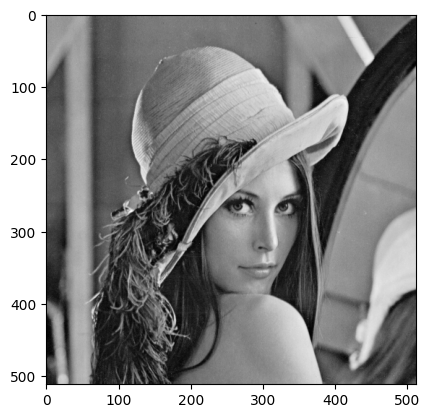

In [ ]:
plt.imshow(R, cmap="gray")

In [ ]:
# Check if the reconstruction is lossless
print((R == Y).all())

True


### Χρήσεις της πυραμίδας Laplacian
[Image Pyramids](http://www.cs.toronto.edu/~jepson/csc320/notes/pyramids.pdf)

